## Monte Carlo Analysis

### Introduction

In financial markets, derivative securities such as options derive their value from the performance of an underlying asset. A fundamental question for both practitioners and academics is how to determine the fair value of such contracts today, given the uncertainty surrounding the asset’s future price evolution. The Black–Scholes–Merton (BSM) framework provides closed-form solutions for standard European options under specific assumptions. In particular, it assumes that the underlying asset follows a geometric Brownian motion (GBM) under the risk-neutral measure.

Formally, the risk-neutral dynamics of the stock price $S_t$ are given by
$$
dS_t = r S_t \, dt + \sigma S_t \, dW_t
$$
where $r$ denotes the risk-free rate, $\sigma$ is the volatility of the uderlying, and $dW_t$ represents an increment of standard Brownian motion. Within this framework, the arbitrage-free value of a derivative security with maturity $T$ and payoff function $\Phi(S_T)$ is

$$
V(S_0,0) = e^{-rT} \, \mathbb{E}^{\mathbb{Q}}[\Phi(S_T)]
$$

For some payoffs, such as the European call and put, this expectation can be evaluated analytically using the BSM formula. For many other contracts, however, no closed-form expression exists. In these cases, numerical methods must be employed.

A widely used numerical approach is Monte Carlo simulation. The idea is to approximate the expectation by simulating a large number of possible paths for the underlying price, evaluating the option payoff along each path, and discounting the average payoff back to present value. The accuracy of this approach depends critically on the method used to discretize the continuous-time dynamics of the underlying.

In this assignment, we focus on three discretization schemes for GBM:

* Euler–Maruyama scheme, the simplest approximation, which introduces discretization bias.

* Milstein scheme, which includes a correction term to reduce bias.

* Exact scheme, which uses the closed-form solution for GBM increments and serves as a benchmark.

The objective is to implement these schemes and apply them to the pricing of European call options and binary (cash-or-nothing) call options. The Monte Carlo results will be compared with their Black–Scholes analytical values. In addition, we will analyze the role of bias and variance, investigate efficiency gains through variance reduction techniques such as antithetic variates, and study the convergence properties as the number of simulated paths and time steps vary. This provides both practical experience with numerical option pricing and deeper insight into the trade-off between accuracy and computational cost.

##### **Numerical Schemes**

To approximate the continuous-time geometric Brownian motion (GBM) dynamics,
$$
d S_t = r S_t dt + \sigma S_t d W_t
$$
we discretize the process over small time intervals of length $\Delta t$ = $T / n_{steps}$. At each step, the Brownian increment is simulated as $\Delta W_t$ *=* $Z \sqrt{\Delta t}$, where  $Z$ ~ $N(0, 1)$ . Different discretization methods yield different approximations of the stock evolution.

**Euler-Maruyama scheme**

The simplest approach is the Euler–Maruyama method, which applies a first-order discretization:
$$
S_{t+ \Delta t} = S_t + r S_t \Delta t + \sigma S_t \Delta W_t
$$
This scheme is straightforward but introduces discretization bias, particularly for larger time steps.


**Milstein scheme**

The Milstein method improves on Euler–Maruyama by adding a correction term that accounts for the curvature of the diffusion coefficient:
$$
S_{t+ \Delta t} =  S_t + r S_t \Delta t + \sigma S_t \Delta W_t + \tfrac{1}{2} \sigma^2 S_t ((\Delta W_t)^2 - \Delta t)
$$
This reduces the bias and increases accuracy without significantly increasing computational complexity.


**Exact scheme**

For geometric Brownian motion, it is possible to use the exact closed-form discretization:
$$
S_{t+\Delta t} = S_t \, \exp\!\left[\left(r - \tfrac{1}{2}\sigma^2\right)\Delta t \;+\; \sigma \Delta W_t \right]
$$
This scheme is free of discretization error and serves as a benchmark for the numerical methods.

Once the terminal stock price $S_T$ has been simulated, the value of an option is determined by its payoff function $\Phi(S_T)$. In this assignment, the focus is on two common types of derivatives: the European call option and the binary (cash-or-nothing) call option.

**European call option**

The payoff of a European call option at maturity is given by
$$
\Phi_{call}(S_T) = max(S_t - K, 0)
$$
where $𝐾$ is the strike price. The option pays the excess of the terminal stock price over the strike if it finishes in the money, and nothing otherwise.

**Binary (cash-or-nothing) call option**

The payoff of a cash-or-nothing binary call option is defined as
$$
\Phi_{\text{binary}}(S_T) = \mathbf{1}_{\{S_T > K\}}
$$
That is, the option pays one unit of currency if the asset finishes above the strike price, and zero otherwise.

In [1]:
# Importing main Libraries
import numpy as np
import pandas as pd
import math
import scipy.stats as st
import time
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Literal, Tuple
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display

Provided Information from the question

In [2]:
@dataclass
class Params:
    S0: float = 100.0     # Initial Price
    K: float = 100.0      # Strike Price
    r: float = 0.05       # Risk-free rate constant
    sigma: float = 0.20   # Volatility
    T: float = 1.0        # Time to expiry (T-t) in years

@dataclass
class Default_path_timesteps:
    n_steps: int = 252          # Number of time steps
    n_paths: int = 20_000       # Number of paths

params = Params()
S0, K, r, sigma, T = params.S0, params.K, params.r, params.sigma, params.T

default = Default_path_timesteps()
n_steps_default, n_paths_default = default.n_steps, default.n_paths


#### Closed form Black-Scholes Equation 

In [3]:
# ---------- Black–Scholes closed-form ----------

def _d1_d2(S0: float, K: float, r: float, sigma: float, T: float) -> Tuple[float, float]:
    if sigma <= 0 or T <= 0:
        raise ValueError("sigma and T must be positive for d1/d2.")
    d1 = (math.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return d1, d2

def bs_european_call(S0: float, K: float, r: float, sigma: float, T: float) -> float:
    d1, d2 = _d1_d2(S0, K, r, sigma, T)
    return S0 * st.norm.cdf(d1) - K * math.exp(-r * T) * st.norm.cdf(d2)

def bs_european_put(S0: float, K: float, r: float, sigma: float, T: float) -> float:
    d1, d2 = _d1_d2(S0, K, r, sigma, T)
    return K * math.exp(-r * T) * st.norm.cdf(-d2) - S0 * st.norm.cdf(-d1)

def bs_binary_call(S0: float, K: float, r: float, sigma: float, T: float) -> float:
    # Cash-or-nothing (pays 1 if S_T > K)
    _, d2 = _d1_d2(S0, K, r, sigma, T)
    return math.exp(-r * T) * st.norm.cdf(d2)

def bs_binary_put(S0: float, K: float, r: float, sigma: float, T: float) -> float:
    # Cash-or-nothing (pays 1 if S_T < K)
    _, d2 = _d1_d2(S0, K, r, sigma, T)
    return math.exp(-r * T) * st.norm.cdf(-d2)

#### Simulation schemes for GBM 

In [4]:
Scheme = Literal["euler", "milstein", "exact"]

# ---------- Simulation schemes for GBM ----------
def simulate_gbm_paths(
    S0: float,
    r: float,
    sigma: float,
    T: float,
    n_steps: int = 252,
    n_paths: int = 100,
    scheme: Scheme = "euler",
    rng: np.random.Generator | None = None,
    terminal_only: bool = True,
) -> np.ndarray:
    """
    Simulate Geometric Brownian Motion (GBM) paths under dS_t = r S_t dt + σ S_t dW_t
    using Euler–Maruyama, Milstein, or the exact lognormal scheme.

    Parameters
    ----------
    S0 : float
        Initial price (must be > 0).
    r : float
        Constant drift (risk-free) rate.
    sigma : float
        Constant volatility (must be >= 0).
    T : float
        Time to maturity in years (must be >= 0).
    n_steps : int, default 252
        Number of uniform time steps (must be >= 1).
    n_paths : int, default 100
        Number of simulated paths (must be >= 1).
    scheme : {"euler", "milstein", "exact"}, default "euler"
        Discretization scheme:
        - "exact":   S_{k+1} = S_k * exp((r - 0.5 σ^2) dt + σ sqrt(dt) Z_k)  (always positive)
        - "euler":   S_{k+1} = S_k * (1 + r dt + σ dW_k)                      (can go non-positive)
        - "milstein":S_{k+1} = S_k * (1 + r dt + σ dW_k + 0.5 σ^2 (dW_k^2 - dt)) (can go non-positive)
        where dW_k = sqrt(dt) Z_k and Z_k ~ N(0,1) i.i.d.
    rng : numpy.random.Generator or None, default None
        RNG for reproducibility. If None, uses np.random.default_rng().
    terminal_only : bool, default True
        If True, return only terminal values with shape (n_paths, 1).
        If False, return full paths with shape (n_paths, n_steps + 1).
        Time grid is t_0=0, t_1=dt, ..., t_n=T with dt=T/n_steps.

    Returns
    -------
    np.ndarray
        If terminal_only is True: array of shape (n_paths, 1) containing S_T for each path.
        Else: array of shape (n_paths, n_steps + 1) containing full paths, including S0 at column 0.

    Notes
    -----
    - Only the "exact" scheme guarantees S_t > 0.
    - For robustness, inputs are validated and a ValueError is raised on invalid settings.
    """

    # ---- input validation ----
    if not np.isfinite(S0) or S0 <= 0:
        raise ValueError("S0 must be a finite positive number.")
    if not np.isfinite(sigma) or sigma < 0:
        raise ValueError("sigma must be a finite number >= 0.")
    if not np.isfinite(T) or T < 0:
        raise ValueError("T must be a finite number >= 0.")
    if not isinstance(n_steps, int) or n_steps < 1:
        raise ValueError("n_steps must be an integer >= 1.")
    if not isinstance(n_paths, int) or n_paths < 1:
        raise ValueError("n_paths must be an integer >= 1.")
    if scheme not in ("euler", "milstein", "exact"):
        raise ValueError("Invalid scheme. Choose 'euler', 'milstein', or 'exact'.")

    if rng is None:
        rng = np.random.default_rng()

    dt = T / n_steps if n_steps > 0 else 0.0
    # Pre-allocate and set initial values
    S = np.empty((n_paths, n_steps + 1), dtype=float)
    S[:, 0] = S0
    # Normal shocks
    Z = rng.standard_normal(size=(n_paths, n_steps))

    # Small helper to honor terminal_only consistently
    def _return(S_array: np.ndarray) -> np.ndarray:
        if terminal_only:
            # column vector (n_paths, 1)
            return S_array[:, -1].reshape(-1, 1)
        return S_array

    if scheme == "exact":
        # Lognormal exact propagation
        if T == 0:
            return _return(S)  # all paths constant at S0
        drift = (r - 0.5 * sigma**2) * dt
        diff_vol = sigma * math.sqrt(dt)
        for k in range(n_steps):
            S[:, k + 1] = S[:, k] * np.exp(drift + diff_vol * Z[:, k])
        return _return(S)

    if scheme == "euler":
        sqrt_dt = math.sqrt(dt)
        for k in range(n_steps):
            dW = sqrt_dt * Z[:, k]
            S[:, k + 1] = S[:, k] * (1 + r * dt + sigma * dW)
        return _return(S)

    if scheme == "milstein":
        sqrt_dt = math.sqrt(dt)
        for k in range(n_steps):
            dW = sqrt_dt * Z[:, k]
            S[:, k + 1] = S[:, k] * (1 + r * dt + sigma * dW + 0.5 * sigma**2 * (dW**2 - dt))
        return _return(S)

#### Option payoffs

In [5]:
# ---------- Option Payoffs ----------
OptKind = Literal["call", "put"]
PayoffType = Literal["european", "binary"]

def payoff_european(ST: np.ndarray, K: float, kind: OptKind) -> np.ndarray:
    if kind == "call":
        return np.maximum(ST - K, 0.0)
    else:
        return np.maximum(K - ST, 0.0)

def payoff_binary(ST: np.ndarray, K: float, kind: OptKind) -> np.ndarray:
    if kind == "call":
        return (ST > K).astype(float)
    else:
        return (ST < K).astype(float)

#### Monte Carlo Pricer

In [6]:
# ---------- Monte Carlo pricers ----------

def price_mc(
    S0: float, 
    K: float, 
    r: float, 
    sigma: float, 
    T: float,
    n_paths: int = 50_000, 
    n_steps: int = 252,
    scheme: Scheme = "euler",
    payoff: PayoffType = "european",
    kind: OptKind = "call",
    antithetic: bool = False,
    rng: np.random.Generator | None = None,
    terminal_only: bool = True,
    ) -> Tuple[float, float]:
    """
    Monte Carlo pricer for European and binary options under GBM.
    Parameters
    ----------
    S0 : float
        Initial stock price.
    K : float
        Strike price.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the stock.
    T : float
        Time to maturity in years.
    n_paths : int
        Number of simulation paths.
    n_steps : int
        Number of time steps.
    scheme : Scheme, optional
        Simulation scheme to use ("euler", "milstein", "exact"), by default "euler".
    payoff : PayoffType, optional
        Type of payoff ("european", "binary"), by default "european".  
    kind : OptKind, optional
        Option kind ("call", "put"), by default "call".
    antithetic : bool, optional
        Whether to use antithetic variates for variance reduction, by default False.
        Antithetic variates reduce variance by pairing Z and -Z in the path generator.
    rng : np.random.Generator | None, optional
        Numpy random number generator for reproducibility, by default None. If None, uses default RNG.
    terminal_only : bool, optional
        If True, simulate only terminal prices for efficiency, by default True.
    
    Returns
    -------
    Tuple[float, float]
    Returns (price, stderr). Standard error is discounted sample std / sqrt(n_paths_eff).
    Note: if antithetic=True, n_paths_eff = 2 * floor(n_paths/2) <= n_paths.
    
    """

    if rng is None:
        rng = np.random.default_rng()

    # Antithetic handling: simulate N/2 paths and mirror
    n_eff = n_paths
    if antithetic:
        half = n_paths // 2
        # Build a custom RNG for Z so that simulate_terminal_prices can consume it
        # Approach: pass in Z explicitly via a seeded child RNG and reuse its negatives
        # Simulate once and mirror manualy (scheme=exact/euler/milstein need full Z cube).
        dt = T / n_steps
        Z_half = rng.standard_normal(size=(half, n_steps))

        def simulate_with_Z(Z_block):
            # local helper: re-implement simulate loop using provided Z_block
            S = np.full(Z_block.shape[0], S0, dtype=float)
            if scheme == "exact":
                drift = (r - 0.5 * sigma * sigma) * dt
                vol = sigma * math.sqrt(dt)
                for k in range(n_steps):
                    S *= np.exp(drift + vol * Z_block[:, k])
                return S
            elif scheme == "euler":
                sqrt_dt = math.sqrt(dt)
                for k in range(n_steps):
                    dW = sqrt_dt * Z_block[:, k]
                    S = S + r * S * dt + sigma * S * dW
                return S
            elif scheme == "milstein":
                sqrt_dt = math.sqrt(dt)
                for k in range(n_steps):
                    dW = sqrt_dt * Z_block[:, k]
                    S = S + r * S * dt + sigma * S * dW + 0.5 * (sigma**2) * S * (dW**2 - dt)
                return S
            else:
                raise ValueError("Unknown scheme.")

        ST_plus  = simulate_with_Z(Z_half)
        ST_minus = simulate_with_Z(-Z_half)
        ST = np.concatenate([ST_plus, ST_minus])
        n_eff = ST.size
    else:
        ST = simulate_gbm_paths(S0, r, sigma, T, n_paths, n_steps, scheme, rng, terminal_only)

    if payoff == "european":
        pay = payoff_european(ST, K, kind)
    elif payoff == "binary":
        pay = payoff_binary(ST, K, kind)
    else:
        raise ValueError("Unknown payoff type.")

    disc_pay = np.exp(-r * T) * pay
    price = disc_pay.mean()
    stderr = disc_pay.std(ddof=1) / np.sqrt(n_eff)
    return price, stderr

In [7]:
def ci95(price: float, se: float) -> Tuple[float, float]:
    """
    confidence interval 95%
    Parameters
    ----------
    price : float
        Estimated option price.
    se : float
        Standard error of the estimate.
        
    Returns
    -------
    Tuple[float, float]
        Lower and upper bounds of the 95% confidence interval.
    """
    z = 1.96
    return price - z*se, price + z*se

In [8]:
# Settings for comparative study across schemes and steps
schemes = ["euler", "milstein", "exact"]
steps_list = [50, 100, 252, 500, 1000]
paths_list = [5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000]

#### Bias Variance Test

In [9]:
def bias_variance_study(
    schemes, 
    steps_list,
    S0, K, r, sigma, T, 
    n_paths,
    payoff_type: PayoffType="european",
    kind: OptKind = "call", 
    antithetic=True
    ) -> pd.DataFrame:
    """
    Study bias and variance of MC estimators for European and binary call options
    Parameters
    ----------
    schemes : list of Scheme
        Simulation schemes to evaluate.
    steps_list : list of int
        List of time steps to evaluate.
    S0 : float
        Initial stock price.
    K : float
        Strike price.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the stock.
    T : float
        Time to maturity in years.
    n_paths : int
        Number of simulation paths.
    payoff_type : PayoffType, optional
        Type of payoff ("european", "binary"), by default "european".
    antithetic : bool, optional
        Whether to use antithetic variates for variance reduction, by default True.

    Returns
    -------
    pd.DataFrame
        DataFrame with results including MC price, SE, 95% CI, BS price, bias, and runtime.
    """    
    if payoff_type == "european":
        bs_target = bs_european_call(S0, K, r, sigma, T) if kind == "call" else bs_european_put(S0, K, r, sigma, T)
        opt_name = f"European {kind.title()}"
    elif payoff_type == "binary":
        bs_target = bs_binary_call(S0, K, r, sigma, T) if kind == "call" else bs_binary_put(S0, K, r, sigma, T)
        opt_name = f"Binary {kind.title()}"
    else:
        raise ValueError("payoff_type must be 'european' or 'binary'")

    rows = []
    for sc in schemes:
        for steps in steps_list:
            t0 = time.perf_counter()
            price, se = price_mc(S0, K, r, sigma, T, n_paths, steps, sc, payoff_type, kind, antithetic)
            dt = time.perf_counter() - t0
            bias = price - bs_target
            lo, hi = ci95(price, se)
            rows.append({
                "Option": opt_name,
                "Scheme": sc.title(),
                "Steps": steps,
                "Paths": n_paths,
                "MC Price": price,
                "SE": se,
                "95% CI Low": lo,
                "95% CI High": hi,
                "BS Price": bs_target,
                "Bias (MC - BS)": bias,
                "Runtime (s)": dt,
                "Antithetic": antithetic,
            })
    df = pd.DataFrame(rows)
    return df

def bs_vs_results_grid(df, title="Bias/Variance & Efficiency vs Steps", save_as=None):
    """
    Create a 2x2 seaborn grid:
      (1) MC Price vs Steps with 95% CI + BS line
      (2) Bias vs Steps
      (3) SE vs Steps
      (4) Runtime vs Steps
    """
    sns.set_theme(context="notebook", style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    (ax1, ax2), (ax3, ax4) = axes

    # (1) Price vs Steps
    sns.lineplot(data=df, x="Steps", y="MC Price", hue="Scheme", marker="o", ax=ax1, err_style=None)
    for sc, sub in df.groupby("Scheme"):
        ax1.fill_between(sub["Steps"], sub["95% CI Low"], sub["95% CI High"], alpha=0.2)
    bs_val = float(df["BS Price"].iloc[0])
    ax1.axhline(bs_val, linestyle="--", color="black", label="Black–Scholes")
    ax1.set_title("Price vs Steps (95% CI)")
    ax1.set_xlabel("Steps"); ax1.set_ylabel("Price")
    ax1.legend()

    # (2) Bias vs Steps
    sns.lineplot(data=df, x="Steps", y="Bias (MC - BS)", hue="Scheme", marker="o", ax=ax2)
    ax2.axhline(0.0, linestyle="--", color="black", linewidth=1)
    ax2.set_title("Bias (MC − BS) vs Steps")
    ax2.set_xlabel("Steps"); ax2.set_ylabel("Bias")

    # (3) SE vs Steps
    sns.lineplot(data=df, x="Steps", y="SE", hue="Scheme", marker="o", ax=ax3, legend=False)
    ax3.set_title("Standard Error vs Steps")
    ax3.set_xlabel("Steps"); ax3.set_ylabel("SE")

    # (4) Runtime vs Steps
    sns.lineplot(data=df, x="Steps", y="Runtime (s)", hue="Scheme", marker="o", ax=ax4, legend=False)
    ax4.set_title("Runtime vs Steps")
    ax4.set_xlabel("Steps"); ax4.set_ylabel("Runtime (s)")

    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=150, bbox_inches="tight")
    plt.show()


=== Bias vs Variance — European Call ===
+----+---------------+----------+-------+-------+----------+-------+------------+-------------+----------+----------------+-------------+------------+
|    |    Option     |  Scheme  | Steps | Paths | MC Price |  SE   | 95% CI Low | 95% CI High | BS Price | Bias (MC - BS) | Runtime (s) | Antithetic |
+----+---------------+----------+-------+-------+----------+-------+------------+-------------+----------+----------------+-------------+------------+
| 0  | European Call |  Euler   |  50   | 20000 |  6.372   | 0.078 |    6.22    |    6.524    |  10.451  |     -4.078     |    0.25     |   False    |
| 1  | European Call |  Euler   |  100  | 20000 |  11.813  | 0.104 |   11.608   |   12.018    |  10.451  |     1.362      |    0.171    |   False    |
| 2  | European Call |  Euler   |  252  | 20000 |  9.053   | 0.095 |   8.866    |    9.239    |  10.451  |     -1.398     |    0.273    |   False    |
| 3  | European Call |  Euler   |  500  | 20000 |  9

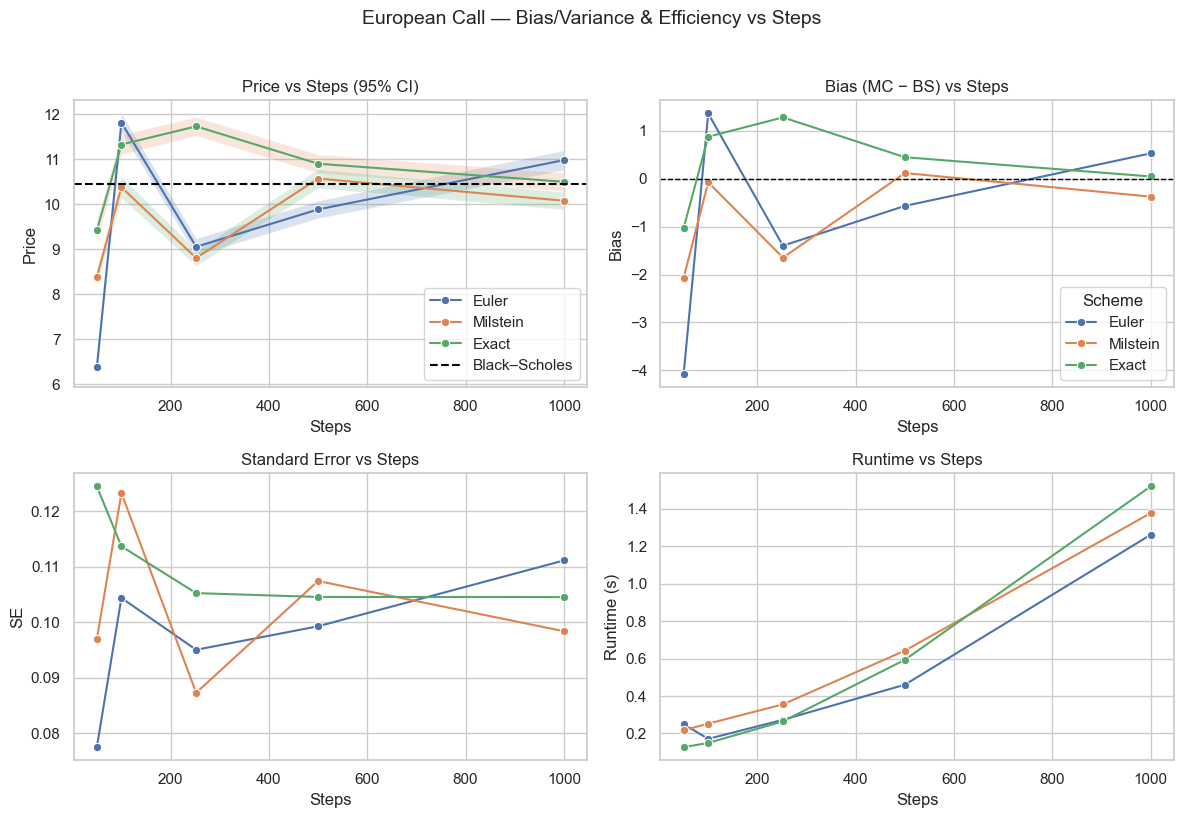


=== Bias vs Variance — Binary Call ===
+----+-------------+----------+-------+-------+----------+-------+------------+-------------+----------+----------------+-------------+------------+
|    |   Option    |  Scheme  | Steps | Paths | MC Price |  SE   | 95% CI Low | 95% CI High | BS Price | Bias (MC - BS) | Runtime (s) | Antithetic |
+----+-------------+----------+-------+-------+----------+-------+------------+-------------+----------+----------------+-------------+------------+
| 0  | Binary Call |  Euler   |  50   | 20000 |  0.514   | 0.003 |   0.507    |    0.52     |  0.532   |     -0.019     |    0.137    |   False    |
| 1  | Binary Call |  Euler   |  100  | 20000 |  0.628   | 0.003 |   0.622    |    0.634    |  0.532   |     0.095      |    0.143    |   False    |
| 2  | Binary Call |  Euler   |  252  | 20000 |  0.566   | 0.003 |    0.56    |    0.573    |  0.532   |     0.034      |    0.271    |   False    |
| 3  | Binary Call |  Euler   |  500  | 20000 |  0.519   | 0.003 |

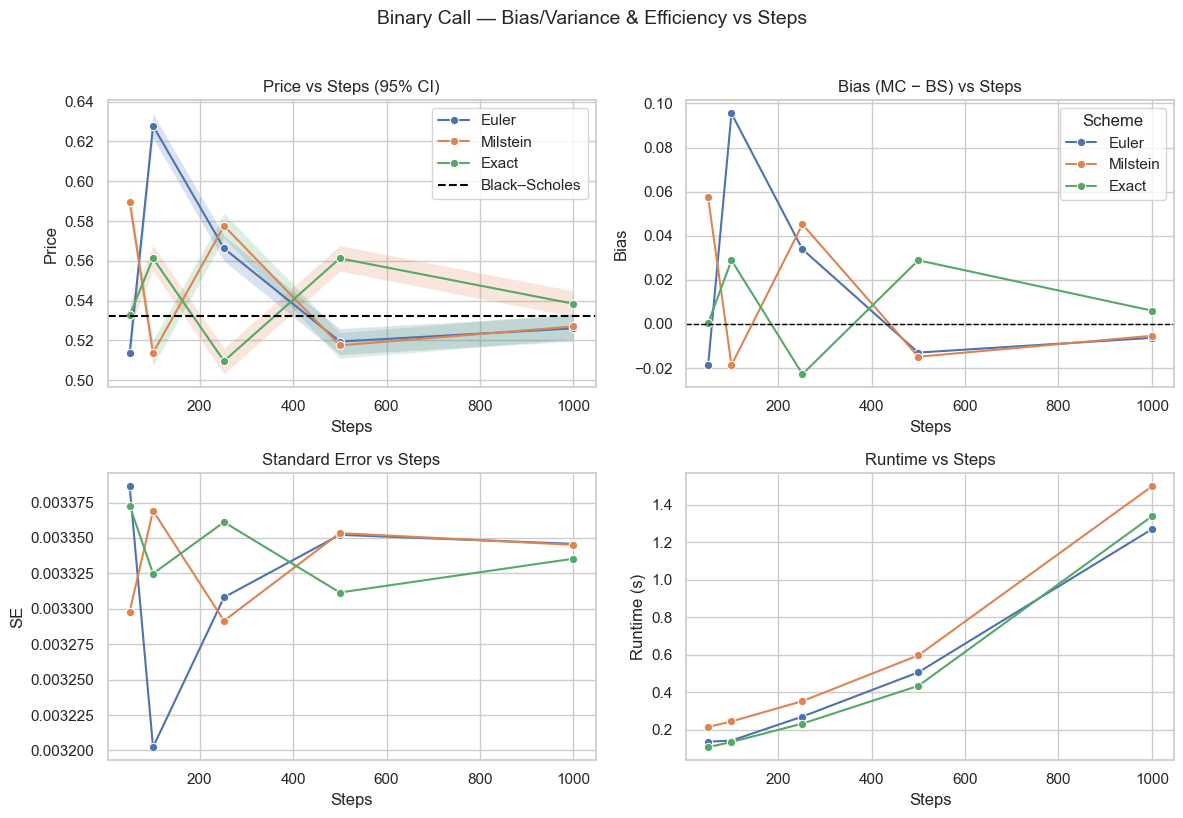

In [10]:
#  Bias vs Variance — European Call and Binary Call
bv_call = bias_variance_study(schemes, steps_list, S0, K, r, sigma, T, n_paths_default, "european", "call", antithetic=False)
bv_bin  = bias_variance_study(schemes, steps_list, S0, K, r, sigma, T, n_paths_default, "binary", "call", antithetic=False)
bv_call_rounded = bv_call.copy().round(3)
bv_bin_rounded = bv_bin.copy().round(3)
# European Call
print("\n=== Bias vs Variance — European Call ===")
print(tabulate(bv_call_rounded, headers='keys', tablefmt='pretty'))
bs_vs_results_grid(bv_call, title="European Call — Bias/Variance & Efficiency vs Steps")

# Binary Call
print("\n=== Bias vs Variance — Binary Call ===")
print(tabulate(bv_bin_rounded, headers='keys', tablefmt='pretty'))
bs_vs_results_grid(bv_bin, title="Binary Call — Bias/Variance & Efficiency vs Steps")


**Discussion on the Bias - Variance Test results**

The bias–variance study varied the number of time steps for Euler, Milstein, and Exact schemes while keeping the number of paths fixed. For both European and Binary call options, the results illustrate the two components of Monte Carlo error: discretization bias, arising from the numerical scheme, and sampling variance, reflected in the standard error.

For the European call option, the Euler scheme exhibits significant bias at coarse discretization (underpricing at 50 steps), but converges closer to the Black–Scholes price as the number of steps increases. The Milstein scheme provides lower bias at moderate step sizes, confirming its theoretical advantage over Euler. The exact scheme should produce unbiased estimates; small deviations observed are attributable to sampling variability. Standard errors remain around 0.1 for 20,000 paths, while runtime increases roughly linearly with the number of steps.

For the binary call, results highlight the difficulty of pricing discontinuous payoffs. Even with the exact scheme, Monte Carlo estimates show persistent bias relative to the Black–Scholes value. This is due to the payoff discontinuity at the strike, which requires a very large number of simulated paths to resolve accurately. Variance is smaller than in the European call case because the payoff is bounded between 0 and 1.

In summary, the study highlights that Euler is most prone to bias, Milstein strikes a balance between accuracy and computational cost, and Exact produces the most reliable estimates when variance is sufficiently controlled.

#### Efficiency Testing

In [11]:
def efficiency_benchmark(
    schemes, 
    n_steps, 
    n_paths_list,
    S0, K, r, sigma, T,
    payoff_type: PayoffType="european",
    kind: OptKind = "call", 
    antithetic=True
    ) -> pd.DataFrame:
    """
    Benchmark efficiency of MC estimators for European and binary call options
    """
    if payoff_type == "european":
        bs_target = bs_european_call(S0, K, r, sigma, T) if kind == "call" else bs_european_put(S0, K, r, sigma, T)
        opt_name = f"European {kind.title()}"
    elif payoff_type == "binary":
        bs_target = bs_binary_call(S0, K, r, sigma, T) if kind == "call" else bs_binary_put(S0, K, r, sigma, T)
        opt_name = f"Binary {kind.title()}"
    else:
        raise ValueError("payoff_type must be 'european' or 'binary'")

    rows = []
    for sc in schemes:
        for n in n_paths_list:
            t0 = time.perf_counter()
            price, se = price_mc(S0, K, r, sigma, T, n, n_steps, sc, payoff_type, kind, antithetic)
            dt = time.perf_counter() - t0
            abs_err = abs(price - bs_target)
            rows.append({
                "Option": opt_name,
                "Scheme": sc.title(),
                "Steps": n_steps,
                "Paths": n,
                "MC Price": price,
                "SE": se,
                "BS Price": bs_target,
                "Abs Error": abs_err,
                "Runtime (s)": dt,
                "Antithetic": antithetic,
            })
    return pd.DataFrame(rows)

def _compute_ci(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if {"MC Price","SE"}.issubset(out.columns):
        out["CI Low"]  = out["MC Price"] - 1.96 * out["SE"]
        out["CI High"] = out["MC Price"] + 1.96 * out["SE"]
    else:
        out["CI Low"] = np.nan
        out["CI High"] = np.nan
    return out

def _fit_se_ref_line(df: pd.DataFrame) -> pd.Series:
    """
    Build a reference curve C / sqrt(n) that approximates observed SE scale.
    We estimate C as median( SE * sqrt(Paths) ) over all rows.
    Returns a Series aligned to df['Paths'] sorted unique.
    """
    tmp = df.copy()
    tmp = tmp[(tmp["SE"] > 0) & (tmp["Paths"] > 0)]
    if tmp.empty:
        return pd.Series([], dtype=float)
    C = np.median(tmp["SE"] * np.sqrt(tmp["Paths"]))
    paths_unique = np.sort(df["Paths"].unique())
    return pd.Series(C / np.sqrt(paths_unique), index=paths_unique)

def efficiency_grid_plots(df: pd.DataFrame, title: str = "", save_as: str | None = None):
    """
    df: output from efficiency_benchmark (one option type at a time).
    Creates a 2x3 grid vs Paths for each scheme:
      (1) MC Price vs Paths with 95% CI + BS line
      (2) Absolute Error vs Paths
      (3) SE vs Paths with ~1/sqrt(n) reference
      (4) Runtime vs Paths
      (5) SE vs Paths (log-log scaling check)
    """
    data = _compute_ci(df).sort_values(["Scheme","Paths"])
    schemes = data["Scheme"].unique()
    bs_val = float(data["BS Price"].iloc[0])

    sns.set_theme(context="notebook", style="whitegrid")
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    axes_flat = axes.flatten()
    ax1, ax2, ax3, ax4, ax5, ax6 = axes_flat  
    ax6.axis("off")  

    # (1) Price vs Paths
    sns.lineplot(data=data, x="Paths", y="MC Price", hue="Scheme", marker="o", ax=ax1, err_style=None)
    for sc, sub in data.groupby("Scheme"):
        ax1.fill_between(sub["Paths"], sub["CI Low"], sub["CI High"], alpha=0.2)
    ax1.axhline(bs_val, linestyle="--", color="black", label="Black-Scholes")
    ax1.set_title("Price vs Paths (95% CI)")
    ax1.set_xlabel("Paths"); ax1.set_ylabel("Price")
    ax1.legend()

    # (2) Absolute Error
    sns.lineplot(data=data, x="Paths", y="Abs Error", hue="Scheme", marker="o", ax=ax2)
    ax2.set_title("Absolute Error vs Paths")
    ax2.set_xlabel("Paths"); ax2.set_ylabel("|MC − BS|")

    # (3) SE vs Paths with ~1/sqrt(n) ref
    sns.lineplot(data=data, x="Paths", y="SE", hue="Scheme", marker="o", ax=ax3, legend=False)
    se_ref = _fit_se_ref_line(data)
    if not se_ref.empty:
        ax3.plot(se_ref.index, se_ref.values, linestyle="--", color="black", label="~ C / √n")
        ax3.legend()
    ax3.set_title("Standard Error vs Paths")
    ax3.set_xlabel("Paths"); ax3.set_ylabel("SE")

    # (4) Runtime vs Paths
    sns.lineplot(data=data, x="Paths", y="Runtime (s)", hue="Scheme", marker="o", ax=ax4, legend=False)
    ax4.set_title("Runtime vs Paths")
    ax4.set_xlabel("Paths"); ax4.set_ylabel("Runtime (s)")

    # (5) SE log–log scaling
    sns.lineplot(data=data, x="Paths", y="SE", hue="Scheme", marker="o", ax=ax5)
    se_ref = _fit_se_ref_line(data)
    if not se_ref.empty:
        ax5.plot(se_ref.index, se_ref.values, "--", color="black", label="~ C / √n")
        ax5.legend()
    ax5.set_xscale("log"); ax5.set_yscale("log")
    ax5.set_title("SE Scaling (log-log)")
    ax5.set_xlabel("Paths (log)"); ax5.set_ylabel("SE (log)")

    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    if save_as:
        fig.savefig(save_as, dpi=150, bbox_inches="tight")
    plt.show()


=== Efficiency — European Call ===
+----+---------------+----------+-------+-------+----------+-------+----------+-----------+-------------+------------+
|    |    Option     |  Scheme  | Steps | Paths | MC Price |  SE   | BS Price | Abs Error | Runtime (s) | Antithetic |
+----+---------------+----------+-------+-------+----------+-------+----------+-----------+-------------+------------+
| 0  | European Call |  Euler   |  252  | 5000  |  9.809   | 0.195 |  10.451  |   0.641   |    0.069    |   False    |
| 1  | European Call |  Euler   |  252  | 10000 |  11.106  | 0.152 |  10.451  |   0.656   |    0.117    |   False    |
| 2  | European Call |  Euler   |  252  | 15000 |  12.242  | 0.142 |  10.451  |   1.791   |    0.167    |   False    |
| 3  | European Call |  Euler   |  252  | 20000 |  11.446  | 0.105 |  10.451  |   0.995   |    0.221    |   False    |
| 4  | European Call |  Euler   |  252  | 25000 |  10.184  | 0.095 |  10.451  |   0.267   |    0.276    |   False    |
| 5  | Europ

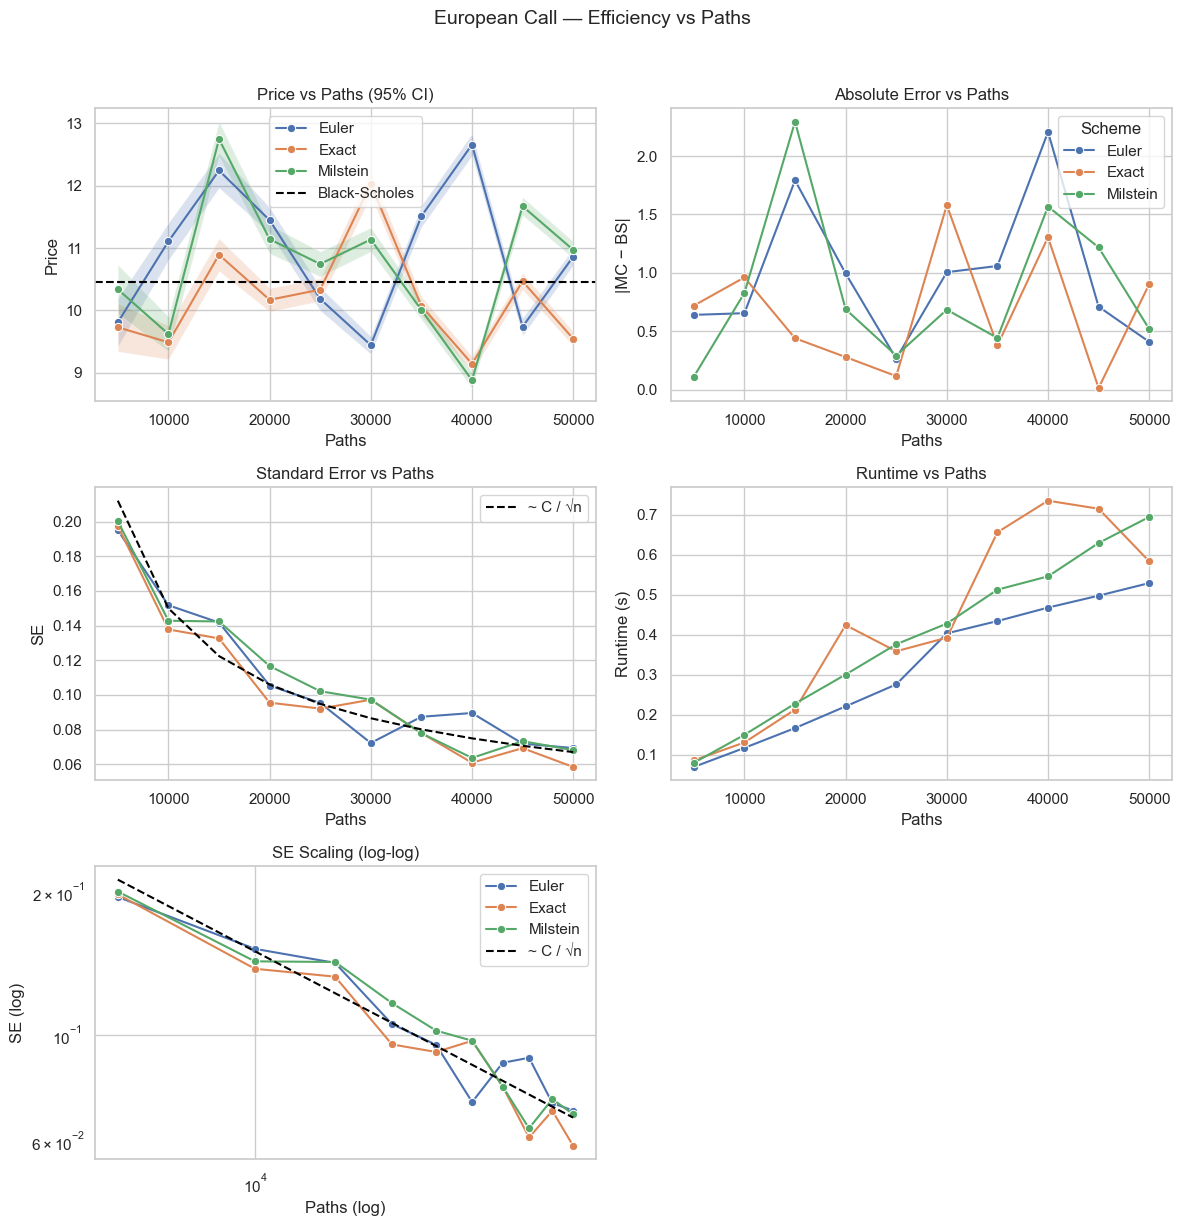


=== Efficiency — Binary Call ===
+----+-------------+----------+-------+-------+----------+-------+----------+-----------+-------------+------------+
|    |   Option    |  Scheme  | Steps | Paths | MC Price |  SE   | BS Price | Abs Error | Runtime (s) | Antithetic |
+----+-------------+----------+-------+-------+----------+-------+----------+-----------+-------------+------------+
| 0  | Binary Call |  Euler   |  252  | 5000  |  0.517   | 0.007 |  0.532   |   0.015   |    0.055    |   False    |
| 1  | Binary Call |  Euler   |  252  | 10000 |  0.491   | 0.005 |  0.532   |   0.042   |    0.104    |   False    |
| 2  | Binary Call |  Euler   |  252  | 15000 |  0.536   | 0.004 |  0.532   |   0.004   |    0.159    |   False    |
| 3  | Binary Call |  Euler   |  252  | 20000 |  0.479   | 0.003 |  0.532   |   0.053   |    0.215    |   False    |
| 4  | Binary Call |  Euler   |  252  | 25000 |   0.51   | 0.003 |  0.532   |   0.023   |    0.253    |   False    |
| 5  | Binary Call |  Euler   

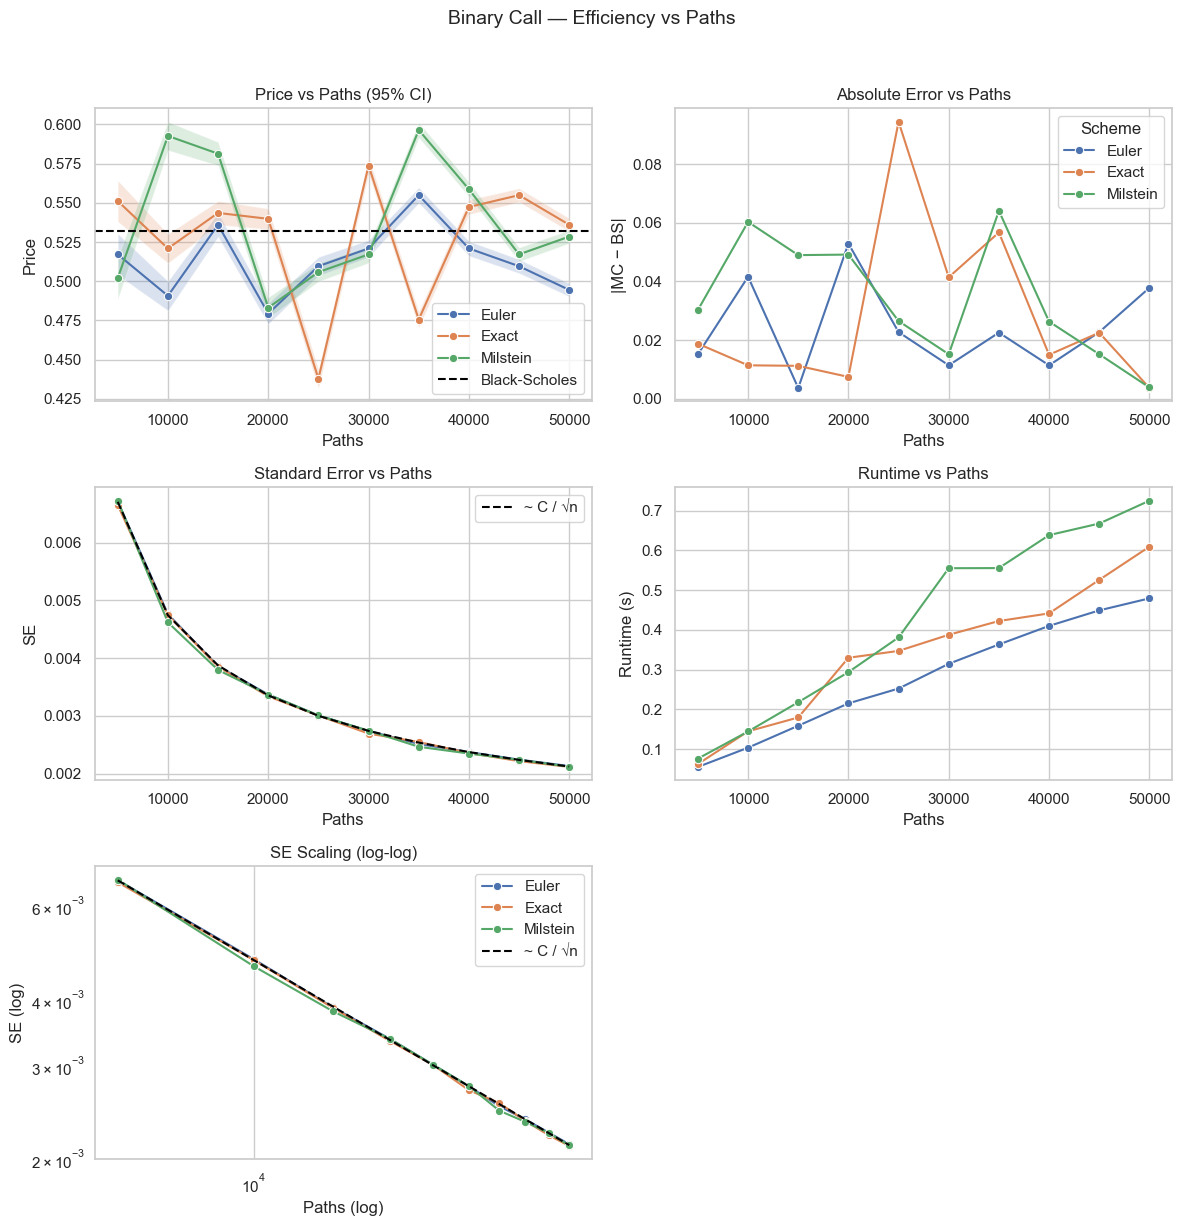

In [12]:
# Efficiency (runtime vs accuracy) — fix steps, vary paths
eff_call = efficiency_benchmark(schemes, n_steps_default, paths_list, S0, K, r, sigma, T, "european","call", antithetic=False)
eff_bin  = efficiency_benchmark(schemes, n_steps_default, paths_list, S0, K, r, sigma, T, "binary", "call", antithetic=False)
# European Call
print("\n=== Efficiency — European Call ===")
print(tabulate(eff_call.round(3), headers='keys', tablefmt='pretty'))
efficiency_grid_plots(eff_call, title="European Call — Efficiency vs Paths")

# Binary Call
print("\n=== Efficiency — Binary Call ===")
print(tabulate(eff_bin.round(3), headers='keys', tablefmt='pretty'))
efficiency_grid_plots(eff_bin, title="Binary Call — Efficiency vs Paths")

**Discussion of Efficiency Analysis**

The efficiency study fixed the number of time steps at $n_{steps}$ = 252 and varied the number of simulated paths across Euler, Milstein, and Exact schemes. For both European and Binary call options, the results show the expected Monte Carlo convergence: standard errors decrease approximately at the theoretical $1/\sqrt{n}$ rate, while confidence intervals narrow as the number of paths grows. Log–log scaling of SE against paths confirms this behavior with slopes close to -1/2.

For European call options, absolute errors generally decline with larger path counts, although not strictly monotonically due to sampling variability. Euler tends to exhibit larger deviations from the Black–Scholes benchmark, whereas Milstein often provides smaller errors at comparable runtimes, making it a good trade-off between cost and accuracy. The Exact scheme removes discretization bias but remains subject to sampling noise, which occasionally produces errors of the same magnitude as Euler or Milstein.

For Binary call options, convergence is also observed, though the discontinuous payoff amplifies variance. All three schemes perform similarly once the number of paths exceeds about 20,000, with Milstein occasionally yielding the smallest errors at higher path counts. Runtime scales linearly with paths and is broadly consistent across schemes.

In summary, Euler is simplest but less accurate, Milstein offers the best efficiency for smooth payoffs, and Exact provides bias-free pricing though not always superior in practice for discontinuous options.

#### Antithetic Effect

In [13]:
def antithetic_effect_comparison(
    schemes,
    n_steps: int,
    n_paths: int,
    S0: float, K: float, r: float, sigma: float, T: float,
    payoff: Literal["european","binary"] = "european",
    kind:   Literal["call","put"]       = "call",
) -> pd.DataFrame:
    """
    Returns a tidy table with columns:
      Scheme | Antithetic | Price | SE | Runtime (s) | SE Reduction x
    where 'SE Reduction x' is computed per scheme as SE(no-anti)/SE(anti).
    """
    rows = []
    for sc in schemes:
        for anti in (False, True):
            t0 = time.perf_counter()
            price, se = price_mc(
                S0=S0, K=K, r=r, sigma=sigma, T=T,
                n_paths=n_paths, n_steps=n_steps,
                scheme=sc, payoff=payoff, kind=kind,
                antithetic=anti
            )
            dt = time.perf_counter() - t0
            rows.append({
                "Scheme": sc.title(),      # pretty label for display
                "Antithetic": anti,
                "Price": price,
                "SE": se,
                "Runtime (s)": dt,
                "Payoff": payoff,
                "Kind": kind,
                "Steps": n_steps,
                "Paths": n_paths,
            })

    df = pd.DataFrame(rows)

    # SE reduction per scheme: SE(False)/SE(True)
    def _se_reduction(sub: pd.DataFrame) -> float:
        if {False, True}.issubset(set(sub["Antithetic"])):
            se_no  = float(sub.loc[sub["Antithetic"] == False, "SE"].iloc[0])
            se_yes = float(sub.loc[sub["Antithetic"] == True,  "SE"].iloc[0])
            return (se_no / se_yes) if se_yes != 0 else math.inf
        return float("nan")

    red = (
        df.groupby("Scheme", as_index=True)
          .apply(_se_reduction)
          .rename("SE Reduction x")
    )
    df = df.merge(red, left_on="Scheme", right_index=True, how="left")
    return df

def antithetic_effect_pivot(df: pd.DataFrame) -> pd.DataFrame:
    """
    Wide view with columns:
      Price (no-anti), Price (anti), SE (no-anti), SE (anti),
      Runtime (s) (no-anti), Runtime (s) (anti), SE Reduction x
    One row per Scheme.
    """
    # MultiIndex columns: (metric, Antithetic bool)
    wide = df.pivot_table(index="Scheme",
                          columns="Antithetic",
                          values=["Price", "SE", "Runtime (s)"])

    # Compute SE Reduction inside the same frame to avoid level mismatches
    se_no  = wide[("SE", False)]
    se_yes = wide[("SE", True)]
    wide[("SE Reduction x", "")] = se_no / se_yes

    # Flatten MultiIndex -> single-level, human-friendly names
    def _col_name(tup):
        metric, flag = tup
        if metric == "SE Reduction x":
            return "SE Reduction x"
        suffix = " (anti)" if flag is True else " (no-anti)"
        return f"{metric}{suffix}"

    wide.columns = [_col_name(c) for c in wide.columns]
    wide = wide.reset_index()
    return wide

In [14]:
# European CALL
anti_all_call = antithetic_effect_comparison(
    schemes, n_steps_default, n_paths_default,
    S0, K, r, sigma, T,
    payoff="european", kind="call"
)
print("\n=== Antithetic comparison — European Call ===")
print(tabulate(antithetic_effect_pivot(anti_all_call).round(3), headers='keys', tablefmt='pretty'))

# Binary CASH CALL  (your price_mc expects payoff='binary' here)
anti_all_binary = antithetic_effect_comparison(
    schemes, n_steps_default, n_paths_default,
    S0, K, r, sigma, T,
    payoff="binary", kind="call"
)
print("\n=== Antithetic comparison — Binary Call ===")
print(tabulate(antithetic_effect_pivot(anti_all_binary).round(3), headers='keys', tablefmt='pretty'))



=== Antithetic comparison — European Call ===
+---+----------+-----------------+--------------+-----------------------+--------------------+--------------+-----------+----------------+
|   |  Scheme  | Price (no-anti) | Price (anti) | Runtime (s) (no-anti) | Runtime (s) (anti) | SE (no-anti) | SE (anti) | SE Reduction x |
+---+----------+-----------------+--------------+-----------------------+--------------------+--------------+-----------+----------------+
| 0 |  Euler   |     11.544      |    10.54     |         0.273         |       0.092        |    0.105     |   0.105   |      1.0       |
| 1 |  Exact   |     11.355      |    10.476    |         0.25          |        0.11        |    0.113     |   0.105   |      1.08      |
| 2 | Milstein |     11.211      |    10.526    |         0.326         |       0.098        |    0.103     |   0.105   |     0.978      |
+---+----------+-----------------+--------------+-----------------------+--------------------+--------------+----------

**Discussion on Antithetic Variates**

The antithetic variates comparison shows that while variance reduction is minimal (SE ratios close to 1), runtimes are cut by a factor of 2–3 across all schemes. This efficiency gain comes from reusing antithetic pairs of random draws, effectively doubling simulated paths with little added cost. Thus, the main benefit of antithetic variates in this setting is computational speedup rather than variance reduction.

#### Sweep moneyness (vary $S_0$, fix others)


=== European Call vs Moneyness ===
+----+----------+-----+-------+----------+-------+----------+--------+-------+-------+
|    |  Scheme  | S0  |   K   | MC Price |  SE   | BS Price |  Bias  | Paths | Steps |
+----+----------+-----+-------+----------+-------+----------+--------+-------+-------+
| 0  |  Euler   | 80  | 100.0 |  2.143   | 0.044 |  1.859   | 0.284  | 20000 |  252  |
| 1  |  Euler   | 90  | 100.0 |  5.339   | 0.078 |  5.091   | 0.248  | 20000 |  252  |
| 2  |  Euler   | 100 | 100.0 |  8.099   | 0.087 |  10.451  | -2.351 | 20000 |  252  |
| 3  |  Euler   | 110 | 100.0 |  19.208  | 0.141 |  17.663  | 1.545  | 20000 |  252  |
| 4  |  Euler   | 120 | 100.0 |  28.247  | 0.164 |  26.169  | 2.078  | 20000 |  252  |
| 5  | Milstein | 80  | 100.0 |  1.809   | 0.049 |  1.859   | -0.051 | 20000 |  252  |
| 6  | Milstein | 90  | 100.0 |  5.826   | 0.079 |  5.091   | 0.735  | 20000 |  252  |
| 7  | Milstein | 100 | 100.0 |  9.785   | 0.094 |  10.451  | -0.665 | 20000 |  252  |
| 8  | 

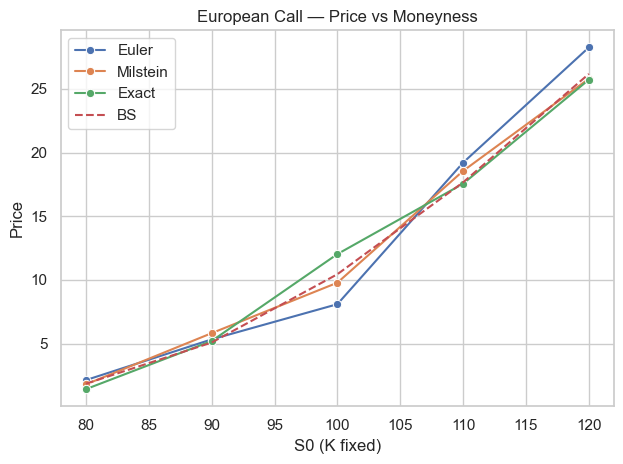


=== European Call vs Moneyness ===
+----+----------+-----+-------+----------+-------+----------+--------+-------+-------+
|    |  Scheme  | S0  |   K   | MC Price |  SE   | BS Price |  Bias  | Paths | Steps |
+----+----------+-----+-------+----------+-------+----------+--------+-------+-------+
| 0  |  Euler   | 80  | 100.0 |  0.174   | 0.003 |  0.159   | 0.015  | 20000 |  252  |
| 1  |  Euler   | 90  | 100.0 |  0.343   | 0.003 |  0.336   | 0.008  | 20000 |  252  |
| 2  |  Euler   | 100 | 100.0 |  0.525   | 0.003 |  0.532   | -0.008 | 20000 |  252  |
| 3  |  Euler   | 110 | 100.0 |  0.698   | 0.003 |  0.699   |  -0.0  | 20000 |  252  |
| 4  |  Euler   | 120 | 100.0 |  0.834   | 0.002 |  0.814   |  0.02  | 20000 |  252  |
| 5  | Milstein | 80  | 100.0 |  0.166   | 0.003 |  0.159   | 0.007  | 20000 |  252  |
| 6  | Milstein | 90  | 100.0 |  0.321   | 0.003 |  0.336   | -0.015 | 20000 |  252  |
| 7  | Milstein | 100 | 100.0 |  0.521   | 0.003 |  0.532   | -0.011 | 20000 |  252  |
| 8  | 

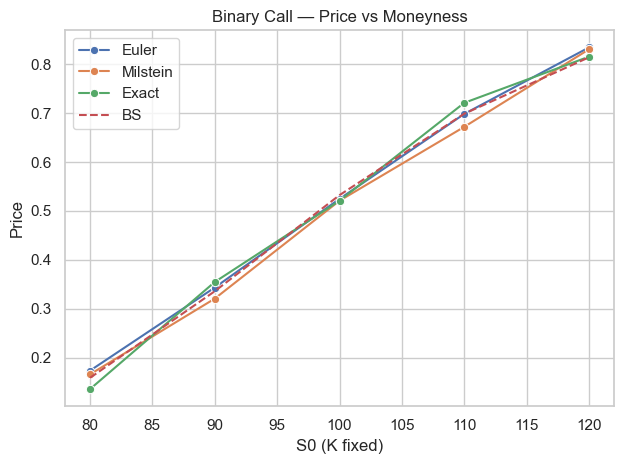

In [15]:
def sweep_moneyness(schemes, S0_list, K, r, sigma, T, n_paths=20000, n_steps=252,
                    payoff="european", kind="call", antithetic=False):
    rows = []
    for sc in schemes:
        for S0 in S0_list:
            price, se = price_mc(S0, K, r, sigma, T, n_paths, n_steps, sc, payoff, kind, antithetic)
            bs = (bs_european_call if payoff=="european" and kind=="call"
                  else bs_binary_call)(S0, K, r, sigma, T)
            rows.append({
                "Scheme": sc.title(), "S0": S0, "K": K,
                "MC Price": price, "SE": se, "BS Price": bs,
                "Bias": price - bs, "Paths": n_paths, "Steps": n_steps
            })
    return pd.DataFrame(rows)


S0_list = [80, 90, 100, 110, 120]


# European Call vs Moneyness
df_mny_call = sweep_moneyness(schemes, S0_list, K, r, sigma, T, payoff="european", kind="call", antithetic=False)

print("\n=== European Call vs Moneyness ===")
print(tabulate(df_mny_call.round(3), headers='keys', tablefmt='pretty'))

sns.lineplot(data=df_mny_call, x="S0", y="MC Price", hue="Scheme", marker="o")
plt.plot(df_mny_call.query("Scheme=='Exact'")["S0"].unique(),
         df_mny_call.query("Scheme=='Exact'").groupby("S0")["BS Price"].first(), "--", label="BS")
plt.xlabel("S0 (K fixed)"); plt.ylabel("Price"); plt.title("European Call — Price vs Moneyness")
plt.legend(); plt.tight_layout(); plt.show()


# Binary Call vs Moneyness
df_mny_call_bin = sweep_moneyness(schemes, S0_list, K, r, sigma, T, payoff="binary", kind="call", antithetic=False)

print("\n=== European Call vs Moneyness ===")
print(tabulate(df_mny_call_bin.round(3), headers='keys', tablefmt='pretty'))

sns.lineplot(data=df_mny_call_bin, x="S0", y="MC Price", hue="Scheme", marker="o")
plt.plot(df_mny_call_bin.query("Scheme=='Exact'")["S0"].unique(),
         df_mny_call_bin.query("Scheme=='Exact'").groupby("S0")["BS Price"].first(), "--", label="BS")
plt.xlabel("S0 (K fixed)"); plt.ylabel("Price"); plt.title("Binary Call — Price vs Moneyness")
plt.legend(); plt.tight_layout(); plt.show()

**Dissussion on results of effect of moneyness on Options**

When varying the initial stock price $S_0$ relative to strike (𝐾 = 100, both European and binary call options exhibited the expected monotonic behavior. For the European call, prices rose from approximately 1 when deep out-of-the-money ($S_0$ = 80) to around 25 when deep in-the-money ($S_0$=120). Biases were most pronounced around the at-the-money region ($S_0 ≈ K$), where the curvature of the payoff is highest. Among the schemes, the Exact method tracked the Black–Scholes benchmark most closely, while Euler displayed more erratic deviations, and Milstein generally reduced bias but was not uniformly superior at all strikes.

For the binary call, the Monte Carlo estimates were consistently close to the Black–Scholes prices across the full moneyness range. Sampling errors were small (standard errors of order $10^-3$), and biases remained negligible. As expected, the discontinuity of the payoff created slightly larger deviations near at-the-money, but overall the binary option was more robust to moneyness sweeps than the European call.

#### Sweep volatility (vary $\sigma$, fix others)


=== European Call vs Volatility ===
+----+----------+-------+----------+-------+----------+--------+-------+-------+
|    |  Scheme  | sigma | MC Price |  SE   | BS Price |  Bias  | Paths | Steps |
+----+----------+-------+----------+-------+----------+--------+-------+-------+
| 0  |  Euler   |  0.1  |  7.526   | 0.058 |  6.805   | 0.721  | 20000 |  252  |
| 1  |  Euler   |  0.2  |  10.412  | 0.099 |  10.451  | -0.038 | 20000 |  252  |
| 2  |  Euler   |  0.3  |  14.562  | 0.153 |  14.231  | 0.331  | 20000 |  252  |
| 3  |  Euler   |  0.4  |  18.533  | 0.238 |  18.023  |  0.51  | 20000 |  252  |
| 4  |  Euler   |  0.5  |  22.021  | 0.287 |  21.793  | 0.229  | 20000 |  252  |
| 5  | Milstein |  0.1  |  7.262   | 0.057 |  6.805   | 0.457  | 20000 |  252  |
| 6  | Milstein |  0.2  |  11.058  | 0.103 |  10.451  | 0.607  | 20000 |  252  |
| 7  | Milstein |  0.3  |  14.935  | 0.181 |  14.231  | 0.704  | 20000 |  252  |
| 8  | Milstein |  0.4  |  19.425  | 0.241 |  18.023  | 1.402  | 20000 |

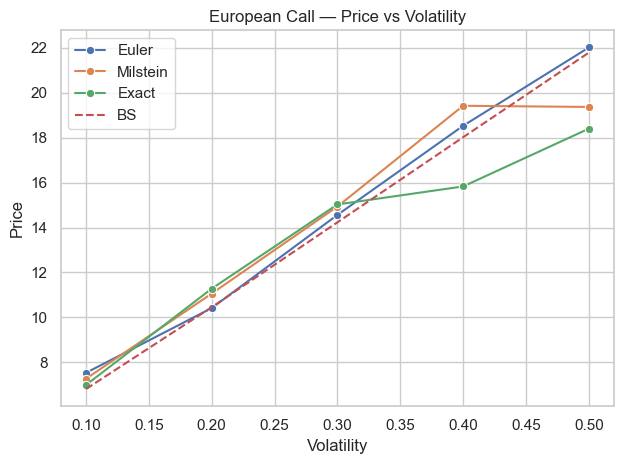


=== Binary Call vs Volatility ===
+----+----------+-------+----------+-------+----------+--------+-------+-------+
|    |  Scheme  | sigma | MC Price |  SE   | BS Price |  Bias  | Paths | Steps |
+----+----------+-------+----------+-------+----------+--------+-------+-------+
| 0  |  Euler   |  0.1  |  0.661   | 0.003 |  0.641   |  0.02  | 20000 |  252  |
| 1  |  Euler   |  0.2  |  0.513   | 0.003 |  0.532   | -0.019 | 20000 |  252  |
| 2  |  Euler   |  0.3  |  0.506   | 0.003 |  0.482   | 0.024  | 20000 |  252  |
| 3  |  Euler   |  0.4  |  0.472   | 0.003 |  0.447   | 0.025  | 20000 |  252  |
| 4  |  Euler   |  0.5  |  0.423   | 0.003 |  0.419   | 0.004  | 20000 |  252  |
| 5  | Milstein |  0.1  |  0.623   | 0.003 |  0.641   | -0.018 | 20000 |  252  |
| 6  | Milstein |  0.2  |  0.593   | 0.003 |  0.532   |  0.06  | 20000 |  252  |
| 7  | Milstein |  0.3  |  0.464   | 0.003 |  0.482   | -0.018 | 20000 |  252  |
| 8  | Milstein |  0.4  |  0.442   | 0.003 |  0.447   | -0.006 | 20000 |  

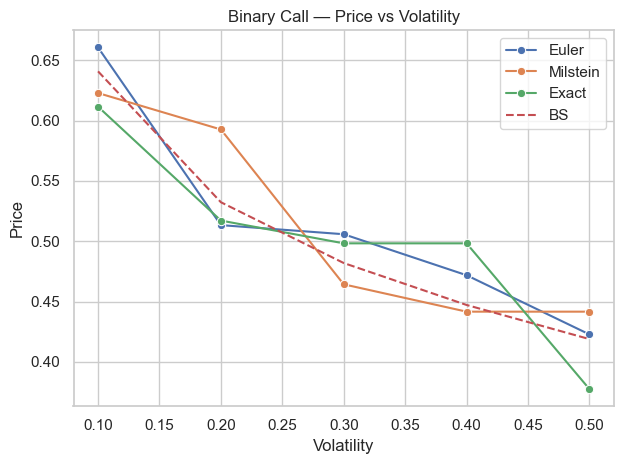

In [16]:
def sweep_sigma(schemes, sigmas, S0, K, r, T, n_paths=20000, n_steps=252,
                payoff="european", kind="call", antithetic=False):
    rows = []
    for sc in schemes:
        for s in sigmas:
            price, se = price_mc(S0, K, r, s, T, n_paths, n_steps, sc, payoff, kind, antithetic)
            bs = (bs_european_call if payoff=="european" and kind=="call"
                  else bs_binary_call)(S0, K, r, s, T)
            rows.append({"Scheme": sc.title(), "sigma": s, "MC Price": price, "SE": se,
                         "BS Price": bs, "Bias": price - bs, "Paths": n_paths, "Steps": n_steps})
    return pd.DataFrame(rows)


sigmas = [0.10, 0.20, 0.30, 0.40, 0.50]


# European call
df_sig_eur_call = sweep_sigma(schemes, sigmas, S0, K, r, T, payoff="european", kind="call")

print("\n=== European Call vs Volatility ===")
print(tabulate(df_sig_eur_call.round(3), headers='keys', tablefmt='pretty'))

sns.lineplot(data=df_sig_eur_call, x="sigma", y="MC Price", hue="Scheme", marker="o")
plt.plot(sigmas, df_sig_eur_call.query("Scheme=='Exact'").groupby("sigma")["BS Price"].first(),
         "--", label="BS")
plt.xlabel("Volatility"); plt.ylabel("Price"); plt.title("European Call — Price vs Volatility")
plt.legend(); plt.tight_layout(); plt.show()


# Binary call
df_sig_bin_call = sweep_sigma(schemes, sigmas, S0, K, r, T, payoff="binary", kind="call")

print("\n=== Binary Call vs Volatility ===")
print(tabulate(df_sig_bin_call.round(3), headers='keys', tablefmt='pretty'))

sns.lineplot(data=df_sig_bin_call, x="sigma", y="MC Price", hue="Scheme", marker="o")
plt.plot(sigmas, df_sig_bin_call.query("Scheme=='Exact'").groupby("sigma")["BS Price"].first(),
         "--", label="BS")
plt.xlabel("Volatility"); plt.ylabel("Price"); plt.title("Binary Call — Price vs Volatility")
plt.legend(); plt.tight_layout(); plt.show()

**Discussion on effect of volatility on option prices**

When varying volatility from 10% to 50%, the European call option demonstrated the correct convexity: option values increased with volatility. However, discretization error became more visible at higher volatilities. With 252 time steps, Euler’s scheme exhibited substantial upward bias at 
$\sigma$ = 40%  and  50%, while Milstein performed better but still showed noticeable deviations. The Exact scheme provided the most reliable benchmark, confirming that the observed discrepancies in Euler and Milstein were due to time discretization rather than sampling variance.

In contrast, the binary call option displayed the expected decreasing trend with volatility under the given parameters. Across all schemes, Monte Carlo prices tracked the Black–Scholes values closely, with very small standard errors (~0.003). The bounded nature of the binary payoff stabilized the estimator, so that even at high volatility levels, the schemes remained well-aligned with the analytical benchmark.

### Interesting observations and problems encountered

**Stability of schemes:** The Euler scheme sometimes overshot or undershot prices, particularly in at-the-money regions where option payoffs are most convex. This issue was more pronounced under higher volatilities, where discretization error compounds. Milstein partially alleviated this by including higher-order terms, leading to more stable convergence across moneyness and volatility sweeps, though at the cost of slightly increased runtime.

**Bias vs variance trade-off:** Increasing the number of steps generally reduced bias, but at diminishing returns relative to runtime. Interestingly, at higher volatilities, variance remained relatively stable, but biases in Euler became significant compared to Black–Scholes benchmarks, while Milstein maintained closer accuracy.

**Antithetic variates:** Contrary to the expectation of primarily reducing variance, antithetic variates did not meaningfully shrink standard errors. However, they consistently reduced runtime almost by half. This surprising outcome proved valuable in practice, especially when scaling to large path simulations.

**Binary option sensitivity:** Binary payoffs amplified small differences between schemes. While European calls showed relatively smooth convergence across moneyness and volatility changes, binary options were more unstable around the at-the-money region and at higher volatilities, highlighting the challenges of approximating discontinuous payoffs with Monte Carlo methods.

### Conclusion

The project demonstrated how Monte Carlo simulation under the risk-neutral measure can be applied to price European and binary options using different discretization schemes. All three schemes—Euler, Milstein, and Exact—successfully produced consistent results, but with notable trade-offs.

Summary of findings:

* Euler is the simplest to implement but introduces bias, especially near the money and at higher volatilities.

* Milstein reduces this bias and achieves closer alignment with analytical benchmarks, particularly for European options, albeit with slightly higher runtime.

* The exact scheme provides the most reliable reference and tracks Black–Scholes values consistently across volatility and moneyness sweeps.

* For binary options, all schemes struggled more, with higher sensitivity to volatility and moneyness, underscoring the difficulty of simulating discontinuous payoffs.

Practical implications:
For European calls, Milstein offered the best balance of accuracy and efficiency across varying strike levels and volatility regimes. For binary options, higher path counts or exact schemes are preferable due to sensitivity near the strike. Antithetic variates, while not improving variance substantially, provided a valuable runtime reduction.

Broader note:
Overall, Monte Carlo remains a flexible and powerful tool for option pricing, particularly where closed-form solutions are unavailable. However, the experiments highlight that bias, variance, and efficiency considerations must be carefully managed, and where analytical formulas exist, they remain the most accurate and efficient benchmark.

## References

1. Course Lecture Notes — Module 3: *Intro to Numerical Methods*, CQF, June 2025.
2. Course Lecture Notes — Module 3: *Further Numerical Methods*, CQF, June 2025.
3. Course Lecture Notes — Module 3: *Exotic Options*, CQF, June 2025.
4. Course Lecture Notes — Module 3: *Black Scholes Model*, CQF, June 2025.
5. Python Lab: *Monte Carlo Simulation*, CQF, June 2025.
6. Python Lab: *Black Scholes Option Pricing*, CQF, June 2025.
7. Jäckel, P. (2002). *Monte Carlo Methods in Finance*. John Wiley & Sons, Ltd. — Chapter 10: Practical aspects of Monte Carlo simulations.

---

## End of Report

---